# Introduction

/to be filled and formatted later

# 1. Import libraries

In [1]:
import kagglehub

/Users/alina_yakubova/Scripts_python3/ml-flight-felay-prediction/ml_unibo/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.reset_option("display.max_rows")
pd.set_option("display.float_format", "{:,.0f}".format)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [3]:
import os

In [4]:
from sklearn.model_selection import train_test_split

In [42]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, TargetEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.decomposition import PCA

# 2. Data import

The following code cell is used to download the dataset files from the Kaggle website. It only needs to be executed once. \
We use library kagglehub, which provides an auth method for logging in through a web page and getting access to Kaggle datasets.

In [6]:
path = kagglehub.dataset_download("threnjen/2019-airline-delays-and-cancellations")

print("Path to dataset files:", path)

Path to dataset files: /Users/alina_yakubova/.cache/kagglehub/datasets/threnjen/2019-airline-delays-and-cancellations/versions/9


In [7]:
df = pd.read_csv(os.path.join(path, "full_data_flightdelay.csv"))

In [78]:
df.head(5)

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,AIRLINE_FLIGHTS_MONTH,AIRLINE_AIRPORT_FLIGHTS_MONTH,AVG_MONTHLY_PASS_AIRPORT,AVG_MONTHLY_PASS_AIRLINE,FLT_ATTENDANTS_PER_PASS,GROUND_SERV_PER_PASS,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,MONTH_NAME,DAY_NAME,DEP_HOUR
0,1,7,0,0800-0859,2,1,25,143,Southwest Airlines Co.,13056,107363,5873,1903352,13382999,0,0,8,McCarran International,36,-115,NONE,0,0,0,65,3,Jan,Sun,8
1,1,7,0,0700-0759,7,1,29,191,Delta Air Lines Inc.,13056,73508,1174,1903352,12460183,0,0,3,McCarran International,36,-115,NONE,0,0,0,65,3,Jan,Sun,7
2,1,7,0,0600-0659,7,1,27,199,Delta Air Lines Inc.,13056,73508,1174,1903352,12460183,0,0,18,McCarran International,36,-115,NONE,0,0,0,65,3,Jan,Sun,6
3,1,7,0,0600-0659,9,1,27,180,Delta Air Lines Inc.,13056,73508,1174,1903352,12460183,0,0,2,McCarran International,36,-115,NONE,0,0,0,65,3,Jan,Sun,6
4,1,7,0,0001-0559,7,1,10,182,Spirit Air Lines,13056,15023,1257,1903352,2688839,0,0,1,McCarran International,36,-115,NONE,0,0,0,65,3,Jan,Sun,0


1) General info

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6489062 entries, 0 to 6489061
Data columns (total 26 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   MONTH                          int64  
 1   DAY_OF_WEEK                    int64  
 2   DEP_DEL15                      int64  
 3   DEP_TIME_BLK                   str    
 4   DISTANCE_GROUP                 int64  
 5   SEGMENT_NUMBER                 int64  
 6   CONCURRENT_FLIGHTS             int64  
 7   NUMBER_OF_SEATS                int64  
 8   CARRIER_NAME                   str    
 9   AIRPORT_FLIGHTS_MONTH          int64  
 10  AIRLINE_FLIGHTS_MONTH          int64  
 11  AIRLINE_AIRPORT_FLIGHTS_MONTH  int64  
 12  AVG_MONTHLY_PASS_AIRPORT       int64  
 13  AVG_MONTHLY_PASS_AIRLINE       int64  
 14  FLT_ATTENDANTS_PER_PASS        float64
 15  GROUND_SERV_PER_PASS           float64
 16  PLANE_AGE                      int64  
 17  DEPARTING_AIRPORT              str    
 18  LATITUDE     

# 3. Data understanding

Descriptive statistics for numerical data

In [21]:
df.describe()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,AIRPORT_FLIGHTS_MONTH,AIRLINE_FLIGHTS_MONTH,AIRLINE_AIRPORT_FLIGHTS_MONTH,AVG_MONTHLY_PASS_AIRPORT,AVG_MONTHLY_PASS_AIRLINE,FLT_ATTENDANTS_PER_PASS,GROUND_SERV_PER_PASS,PLANE_AGE,LATITUDE,LONGITUDE,PRCP,SNOW,SNWD,TMAX,AWND
count,"6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062"
mean,7,4,0,4,3,28,134,"12,685","62,961","3,459","1,588,639","7,814,970",0,0,12,37,-94,0,0,0,71,8
std,3,2,0,2,2,22,46,"8,840","34,382","4,251","1,123,847","5,046,882",0,0,7,6,18,0,0,1,18,4
min,1,1,0,1,1,1,44,"1,100","5,582",1,"70,476","473,794",0,0,0,18,-159,0,0,0,-10,0
25%,4,2,0,2,2,11,90,"5,345","25,034",654,"673,221","2,688,839",0,0,5,33,-106,0,0,0,59,6
50%,7,4,0,3,3,23,143,"11,562","70,878","2,251","1,486,066","8,501,631",0,0,12,38,-88,0,0,0,74,8
75%,10,6,0,5,4,39,172,"17,615","86,312","4,806","2,006,675","12,460,183",0,0,17,41,-81,0,0,0,86,10
max,12,7,1,11,15,109,337,"35,256","117,728","21,837","4,365,661","13,382,999",0,0,32,61,-66,12,17,25,115,34


Descriptive statistics for categorical data

In [22]:
df.describe(include="object")

/var/folders/78/8b3g8thx1b99pgrq0245szkr0000gn/T/ipykernel_26308/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,DEP_TIME_BLK,CARRIER_NAME,DEPARTING_AIRPORT,PREVIOUS_AIRPORT
count,6489062,6489062,6489062,6489062
unique,19,17,96,356
top,0800-0859,Southwest Airlines Co.,Atlanta Municipal,NONE
freq,452391,1296329,392603,1449009


Duplicates

In [7]:
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup:,}  ({n_dup / len(df):.2%})")

Duplicate rows: 28,473  (0.44%)


Drop duplicates

In [8]:
df = df.drop_duplicates().reset_index(drop=True)

Type conversions

- Convert monthes and days of week into strings
- Extract hour from departure time

In [9]:
MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
DOW_ORDER   = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

In [10]:
MONTH_MAP = dict(zip(range(1, 13), MONTH_ORDER))
DOW_MAP   = dict(zip(range(1, 8),  DOW_ORDER))

df["MONTH_NAME"] = pd.Categorical(
    df["MONTH"].map(MONTH_MAP), categories=MONTH_ORDER, ordered=True
)
df["DAY_NAME"] = pd.Categorical(
    df["DAY_OF_WEEK"].map(DOW_MAP), categories=DOW_ORDER, ordered=True
)

In [11]:
df["DEP_HOUR"] = df["DEP_TIME_BLK"].str[:2].astype(int)

df[["MONTH","MONTH_NAME","DAY_OF_WEEK","DAY_NAME",
    "DEP_TIME_BLK","DEP_HOUR"]].head(3)

,MONTH,MONTH_NAME,DAY_OF_WEEK,DAY_NAME,DEP_TIME_BLK,DEP_HOUR
0,1,Jan,7,Sun,0800-0859,8
1,1,Jan,7,Sun,0700-0759,7
2,1,Jan,7,Sun,0600-0659,6


In [12]:
df["TMAX_C"] = (df["TMAX"] - 32) * 5 / 9

Target distribution (total on-time vs delayed)

In [ ]:
def plot_target_distribution(df, target="DEP_DEL15"):
    """
    Bar chart showing class balance for a binary target column.
    """
    counts = df[target].value_counts().sort_index()
    labels = ["On Time", "Delayed (>15 min)"]
    colors = ["steelblue", "tomato"]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)

    ax.set_ylim(0, max(counts.values) * 1.2)

    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{val:,}\n({val / len(df):.1%})",
            ha="center", va="bottom", fontsize=11,
        )
    ax.set_title("Flight Delay Distribution (DEP_DEL15)", fontsize=13)
    ax.set_ylabel("Number of Flights")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
    plt.tight_layout()
    plt.show()

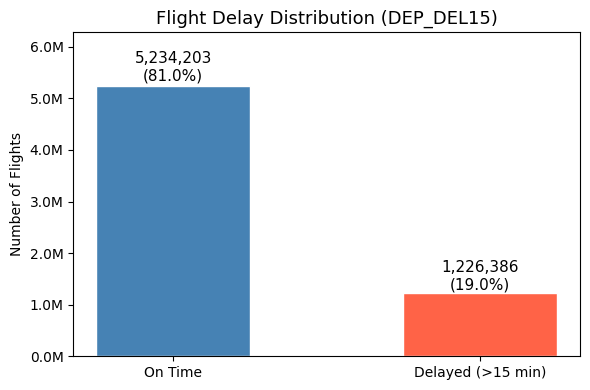

In [41]:
plot_target_distribution(df)

## Categorical feature histograms

In [55]:
def plot_categorical_histogram(df, col, top_n=20, figsize=(12, 4),
                               category_order=None):
    """
    Bar chart for a categorical column with delay rate overlay.
    
    col            : column name
    top_n          : keep top N categories by count (ignored if category_order given)
    category_order : explicit list to fix x-axis order (e.g. month names)
    """
    if category_order:
        counts = df[col].value_counts().reindex(category_order).dropna()
    else:
        counts = df[col].value_counts().head(top_n)

    delay_rate = df.groupby(col)["DEP_DEL15"].mean().reindex(counts.index)

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.bar(counts.index.astype(str), counts.values,
            color="steelblue", alpha=0.85, label="Flight Count")
    ax1.set_ylabel("Flight Count", color="steelblue")
    ax1.tick_params(axis="x", rotation=45)
    plt.setp(ax1.get_xticklabels(), ha="right", rotation_mode="anchor")
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K" if x < 1e6 else f"{x/1e6:.1f}M")
    )

    ax2 = ax1.twinx()
    ax2.plot(counts.index.astype(str), delay_rate.values,
             "o-", color="tomato", linewidth=2, label="Delay Rate")
    ax2.set_ylabel("Delay Rate", color="tomato")
    ax2.set_ylim(0, 0.5)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))

    lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax1.legend(lines, labels, loc="upper right", fontsize=8)
    ax1.set_title(f"{col} — Flight Count & Delay Rate", fontsize=11)

    plt.tight_layout()
    plt.show()

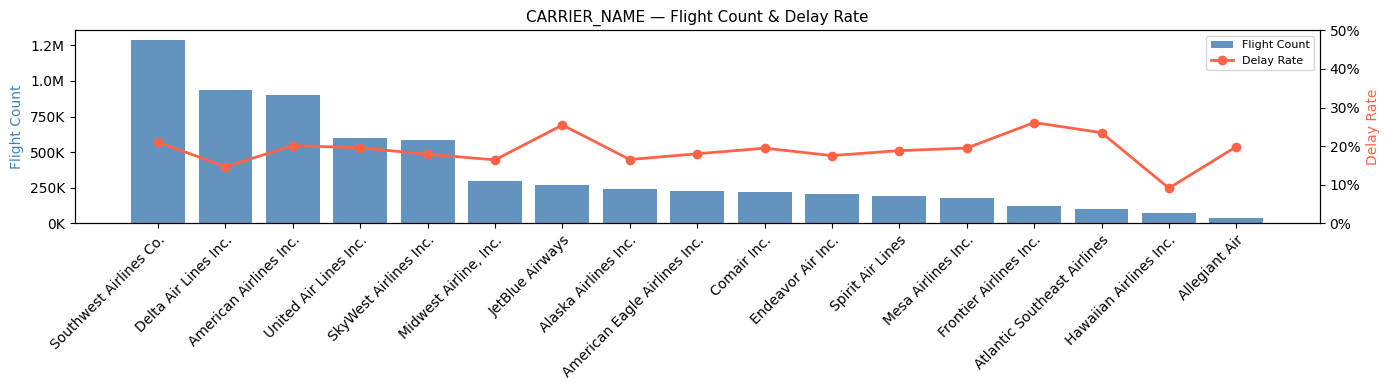

In [ ]:
plot_categorical_histogram(df, "CARRIER_NAME", figsize=(14, 4))

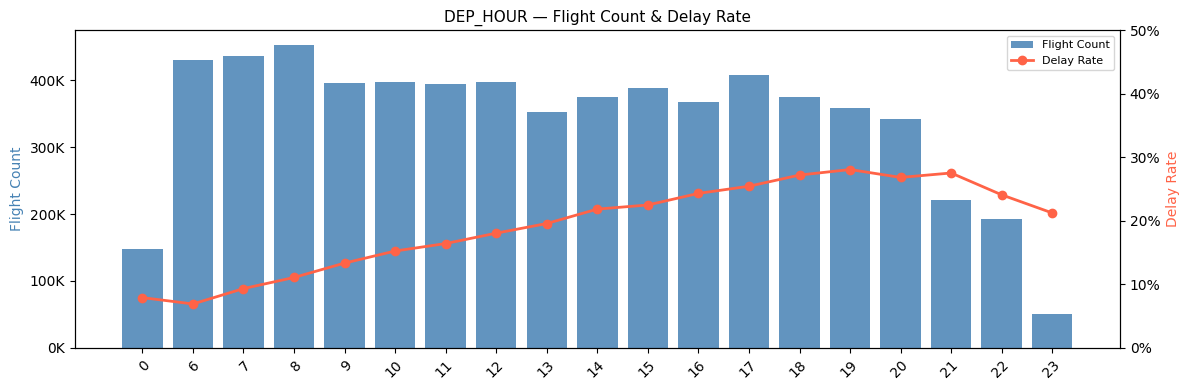

In [57]:
plot_categorical_histogram(df, "DEP_HOUR", category_order = list(range(24)))

Check if there actually is no flight data for the interval: 01-05

In [59]:
df.iloc[df["DEP_HOUR"].isin([1,2,3,4,5])].head(3)

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,AIRLINE_FLIGHTS_MONTH,AIRLINE_AIRPORT_FLIGHTS_MONTH,AVG_MONTHLY_PASS_AIRPORT,AVG_MONTHLY_PASS_AIRLINE,FLT_ATTENDANTS_PER_PASS,GROUND_SERV_PER_PASS,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,MONTH_NAME,DAY_NAME,DEP_HOUR


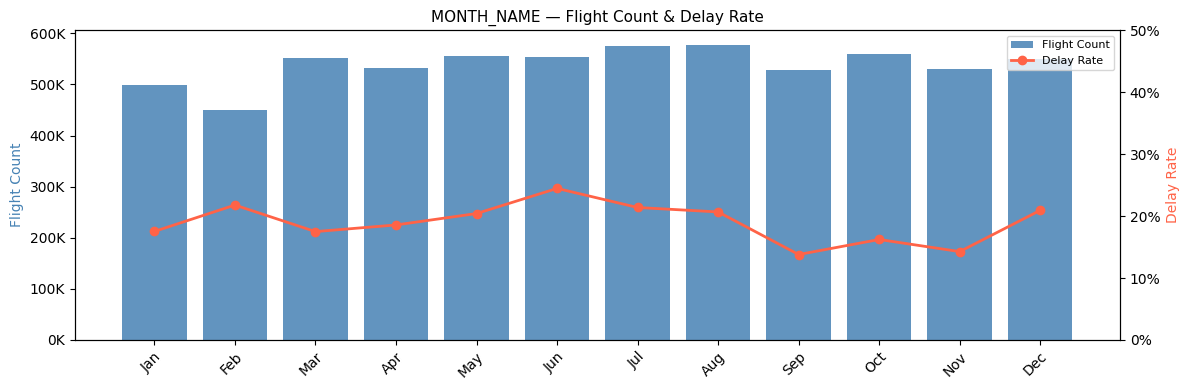

In [49]:
plot_categorical_histogram(df, "MONTH_NAME",  category_order=MONTH_ORDER)

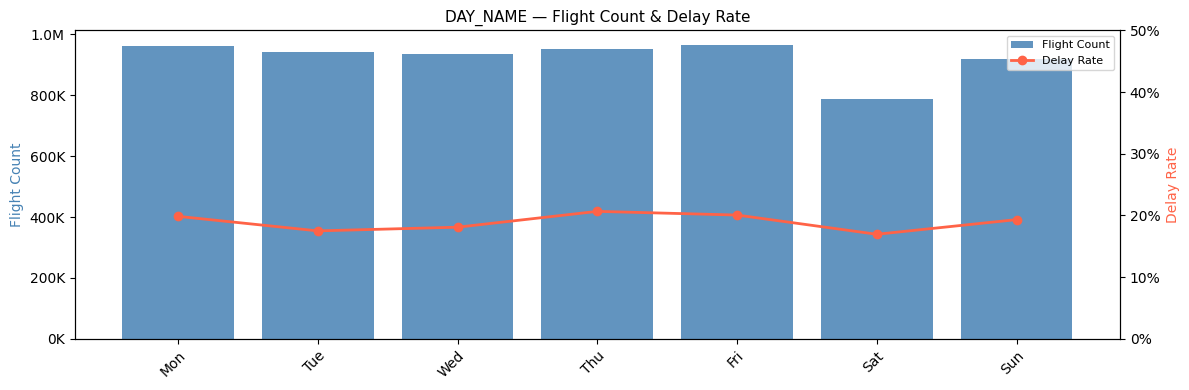

In [50]:
plot_categorical_histogram(df, "DAY_NAME",    category_order=DOW_ORDER)

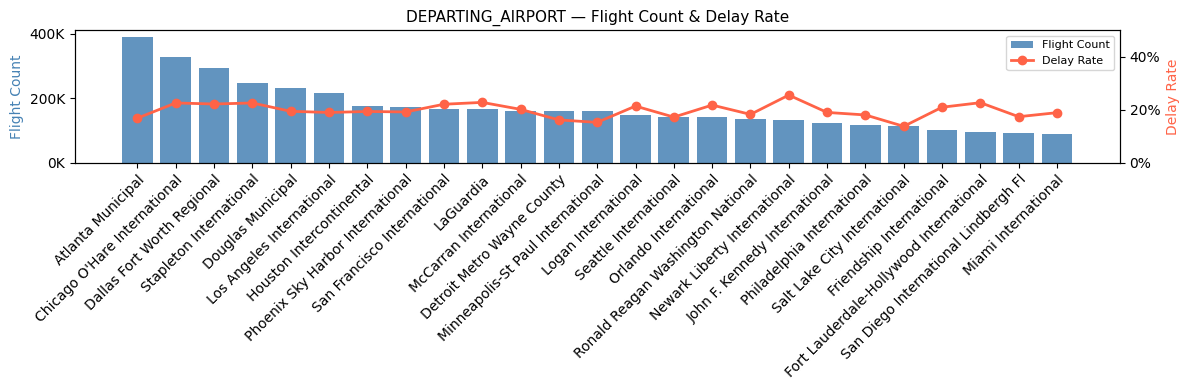

In [51]:
plot_categorical_histogram(df, "DEPARTING_AIRPORT", top_n=25)

Key takeways:
- Delay rate generally increases from early morning to evening, peaking around 18-21. The trend is mostly upward, but not perfectly linear.
- Delay rate varies by month: it is lower in September and November, and higher in February, June, and December.
- Day of week does not show a strong pattern. Delay rate stays relatively stable, around 17-21%, across all days.
- Delay rate differs across both airports and carriers. The variation is more pronounced for carriers, while airport-level differences are present but less consistent.

## Box plot diagrams

- Balanced stratified sample for faster boxplot rendering.
- Equal target/non-target counts; fewer outlier points to draw.

In [67]:
SAMPLE_N = 600_000

In [50]:
BOXPLOT_COLS = [
    "CONCURRENT_FLIGHTS", "NUMBER_OF_SEATS", "PLANE_AGE",
    "PRCP", "SNOW", "TMAX", "AWND",
    "SEGMENT_NUMBER", "DISTANCE_GROUP", "DEP_HOUR",
]

In [53]:
def plot_delay_boxplots(df, cols, ncols=2, sample_n=SAMPLE_N):
    '''Grid of boxplots for numeric features split by on-time vs delayed.'''
    on_time = df[df["DEP_DEL15"] == 0].sample(n=min(sample_n // 2, len(df[df["DEP_DEL15"] == 0])), random_state=42)
    delayed = df[df["DEP_DEL15"] == 1].sample(n=min(sample_n // 2, len(df[df["DEP_DEL15"] == 1])), random_state=42)
    sample  = pd.concat([on_time, delayed]).reset_index(drop=True)

    nrows  = (len(cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 9, nrows * 6))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        sns.boxplot(
            data=sample, x="DEP_DEL15", y=col, ax=axes[i],
            hue="DEP_DEL15", palette=["steelblue", "tomato"],
            whis=1.5,
            flierprops=dict(marker=".", markersize=1, alpha=0.2, linestyle="none"),
            legend=False,
        )
        axes[i].set_title(col, fontsize=17)
        axes[i].set_xlabel("0 = On-time  |  1 = Delayed", fontsize=14)
        axes[i].tick_params(labelsize=14)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle("Feature Distributions: On-time vs Delayed", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

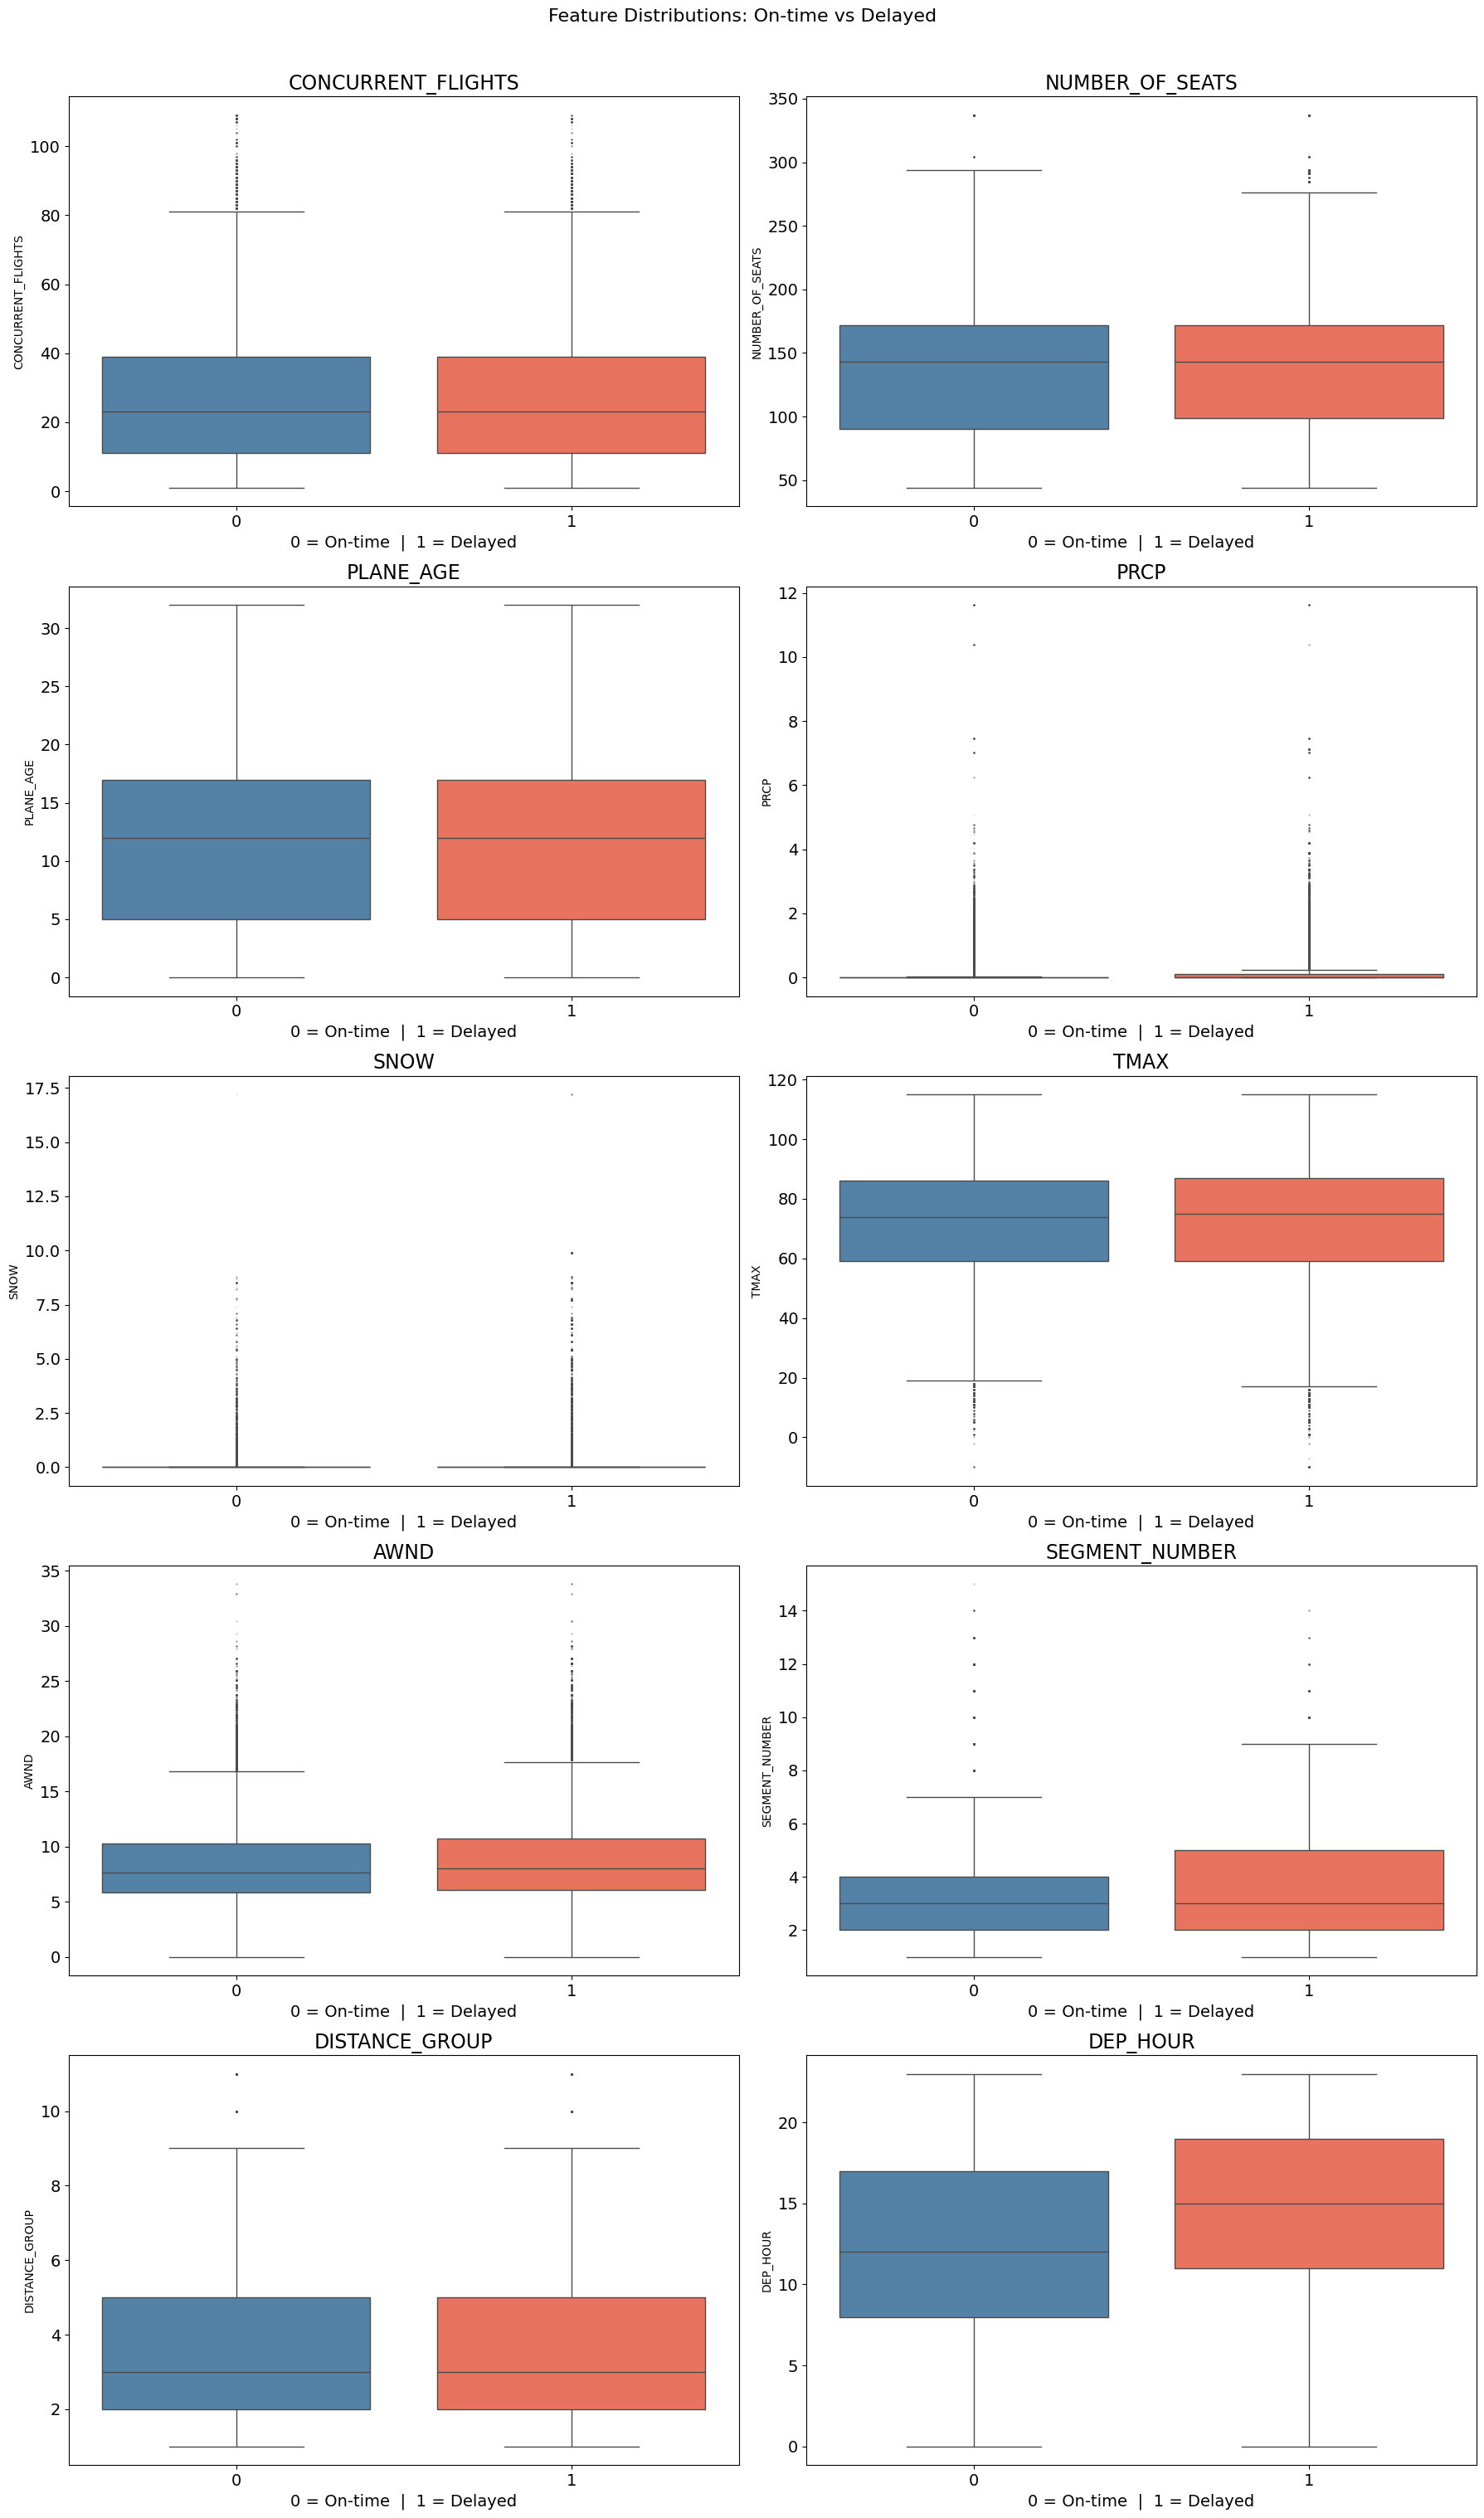

In [54]:
plot_delay_boxplots(df, BOXPLOT_COLS, ncols=2)

- The boxplots show that most numeric features have very similar distributions for on-time and delayed flights. The clearest visible differences are in DEP_HOUR, where delayed flights tend to depart later, and slightly in weather-related features such as PRCP, SNOW, and AWND.

- For SNOW, both classes are heavily concentrated at zero, meaning most flights happened with no snowfall. Delayed flights show a slightly denser upper tail, suggesting that snow events are rare but may be more associated with delays when they occur.

Dive deeper into DEP_HOUR category 

In [74]:
def plot_boxplot_by_category(df, x_col, y_col, top_n=15,
                              sample_n=SAMPLE_N, figsize=(14, 5)):
    '''Boxplot of a numeric feature grouped by a categorical column.
    Sorted by median; top_n categories by flight count.
    Proportional stratified sample preserving 81/19 class ratio.'''
    on_time = df[df["DEP_DEL15"] == 0].sample(n=int(sample_n * 0.81), random_state=42)
    delayed = df[df["DEP_DEL15"] == 1].sample(n=int(sample_n * 0.19), random_state=42)
    sample  = pd.concat([on_time, delayed]).reset_index(drop=True)

    data = sample.copy()
    order = list(range(24))
    order = [x for x in order if x in data[x_col].values]

    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(
        data=data, x=x_col, y=y_col, order=order, ax=ax,
        hue=x_col, palette="muted", whis=1.5, legend=False,
        flierprops=dict(marker=".", markersize=1, alpha=0.2, linestyle="none"),
    )
    ax.set_title(f"{y_col} by {x_col}", fontsize=12)
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
    plt.tight_layout()
    plt.show()

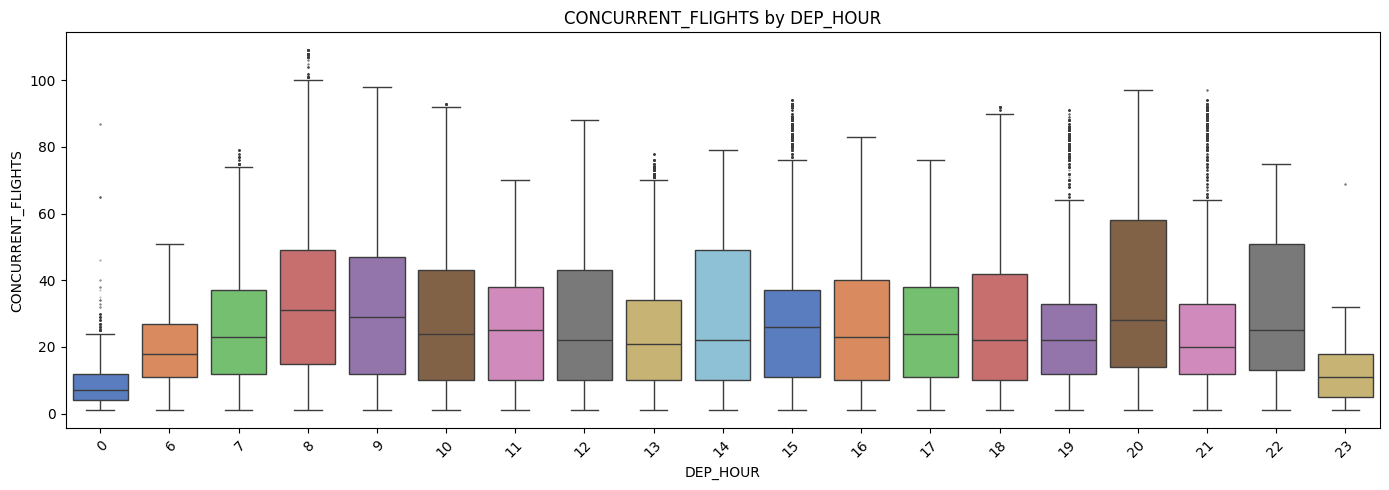

In [75]:
plot_boxplot_by_category(df, "DEP_HOUR", "CONCURRENT_FLIGHTS", top_n=24)

- Concurrent flights vary by departure hour. 
- The lowest congestion appears at night and very late hours, while morning and evening periods show higher medians and wider ranges, suggesting heavier airport traffic during peak operating hours.


# 4. Data Quality

Missing values (NaN)

In [76]:
missing = df.isnull().sum()
missing_nonzero = missing[missing > 0]

if missing_nonzero.empty:
    print("No NaN values found in any column.")
else:
    display(
        missing_nonzero
        .to_frame("null_count")
        .assign(pct=lambda x: (x["null_count"] / len(df) * 100).round(2))
    )

No NaN values found in any column.


Check PREVIOUS_AIRPORT = None, is it always a first flight?

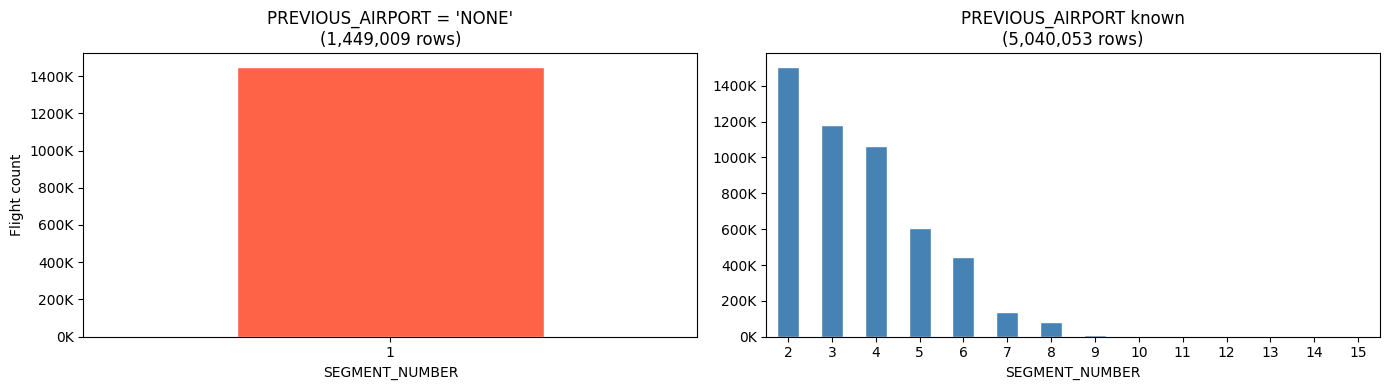

In [81]:
none_mask = df["PREVIOUS_AIRPORT"] == "NONE"

seg_none  = df[none_mask]["SEGMENT_NUMBER"].value_counts().sort_index()
seg_known = df[~none_mask]["SEGMENT_NUMBER"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

seg_none.plot(kind="bar", ax=axes[0], color="tomato", edgecolor="white")
axes[0].set_title(f"PREVIOUS_AIRPORT = 'NONE'\n({none_mask.sum():,} rows)")
axes[0].set_xlabel("SEGMENT_NUMBER")
axes[0].set_ylabel("Flight count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0].tick_params(axis="x", rotation=0)   # только "1" — rotation не нужен

seg_known.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title(f"PREVIOUS_AIRPORT known\n({(~none_mask).sum():,} rows)")
axes[1].set_xlabel("SEGMENT_NUMBER")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[1].tick_params(axis="x", rotation=0)   # числа 2-15, помещаются горизонтально

plt.tight_layout()
plt.show()


In [82]:
seg1 = df[df["SEGMENT_NUMBER"] == 1]
pct_none_in_seg1    = (seg1["PREVIOUS_AIRPORT"] == "NONE").mean() * 100
pct_none_not_seg1   = (df[none_mask]["SEGMENT_NUMBER"] != 1).mean() * 100

print(f"Segment 1  →  PREVIOUS_AIRPORT = 'NONE': {pct_none_in_seg1:.1f}%")
print(f"NONE  →  segment > 1 (anomalies):         {pct_none_not_seg1:.1f}%")

Segment 1  →  PREVIOUS_AIRPORT = 'NONE': 100.0%
NONE  →  segment > 1 (anomalies):         0.0%


4.1 Data sanity checks

Integers are less then 0

In [101]:
def check_positive(df, cols):
    """
    For each column: count zeros, negatives, and positives.
    Use for columns where 0 or negative values are suspicious.
    """
    rows = []
    for col in cols:
        total = len(df)
        n_neg  = (df[col] < 0).sum()
        n_zero = (df[col] == 0).sum()
        n_pos  = (df[col] > 0).sum()
        rows.append({
            "column":    col,
            "negative":  f"{n_neg:,}  ({n_neg/total:.2%})",
            "zero":      f"{n_zero:,}  ({n_zero/total:.2%})",
            "positive":  f"{n_pos:,}  ({n_pos/total:.2%})",
        })
    return pd.DataFrame(rows).set_index("column")


In [102]:
check_positive(df, [
    "NUMBER_OF_SEATS", "CONCURRENT_FLIGHTS", "PLANE_AGE",
    "AIRPORT_FLIGHTS_MONTH", "AIRLINE_FLIGHTS_MONTH",
    "AIRLINE_AIRPORT_FLIGHTS_MONTH", "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE", "AWND", "TMAX_C",
])

,negative,zero,positive
column,,,
NUMBER_OF_SEATS,0 (0.00%),0 (0.00%),"6,489,062 (100.00%)"
CONCURRENT_FLIGHTS,0 (0.00%),0 (0.00%),"6,489,062 (100.00%)"
PLANE_AGE,0 (0.00%),"120,148 (1.85%)","6,368,914 (98.15%)"
AIRPORT_FLIGHTS_MONTH,0 (0.00%),0 (0.00%),"6,489,062 (100.00%)"
AIRLINE_FLIGHTS_MONTH,0 (0.00%),0 (0.00%),"6,489,062 (100.00%)"
AIRLINE_AIRPORT_FLIGHTS_MONTH,0 (0.00%),0 (0.00%),"6,489,062 (100.00%)"
AVG_MONTHLY_PASS_AIRPORT,0 (0.00%),0 (0.00%),"6,489,062 (100.00%)"
AVG_MONTHLY_PASS_AIRLINE,0 (0.00%),0 (0.00%),"6,489,062 (100.00%)"
AWND,0 (0.00%),518 (0.01%),"6,488,544 (99.99%)"


Max temperature range

In [103]:
print(f"TMAX_C range: {df['TMAX_C'].min():.1f}°C  –  {df['TMAX_C'].max():.1f}°C")

TMAX_C range: -23.3°C  –  46.1°C


Suspicious zeros

Zero is a valid value for PRCP/SNOW/SNWD, but it is suspicious for:
- TMAX = 0 in summer — 0°F is approximately −18°C, which is impossible in June–August in the US.
- AWND = 0 — complete calm conditions are very rare at airport weather stations.

In [84]:
WEATHER_COLS = ["PRCP", "SNOW", "SNWD", "TMAX", "AWND"]

Share of zeros per weather column

In [ ]:
zero_stats = pd.DataFrame({
    "zero_count": (df[WEATHER_COLS] == 0).sum(),
    "zero_pct":   (df[WEATHER_COLS] == 0).mean().mul(100).round(2),
})
display(zero_stats)

,zero_count,zero_pct
PRCP,4554778,70
SNOW,6326795,98
SNWD,6316391,97
TMAX,84,0
AWND,518,0


TMAX = 0 split by month — should spike only in Dec/Jan/Feb

In [ ]:
tmax_zero_by_month = (
    df.assign(tmax_is_zero=(df["TMAX"] == 0))
    .groupby("MONTH_NAME")["tmax_is_zero"]
    .mean()
    .mul(100)
    .reindex(MONTH_ORDER)
)

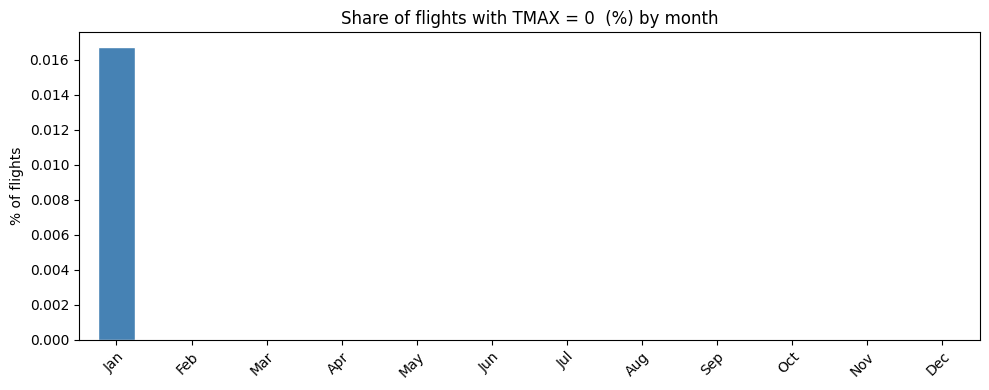

In [87]:
fig, ax = plt.subplots(figsize=(10, 4))
tmax_zero_by_month.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Share of flights with TMAX = 0  (%) by month")
ax.set_ylabel("% of flights")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

-  No suspicious data with 0 in summer

 1) Snow only in winter (SNOW ~ MONTH)

In [89]:
snow_by_month = (
    df.assign(has_snow=(df["SNOW"] > 0))
    .groupby("MONTH_NAME")["has_snow"]
    .mean()
    .mul(100)
    .reindex(MONTH_ORDER)
)

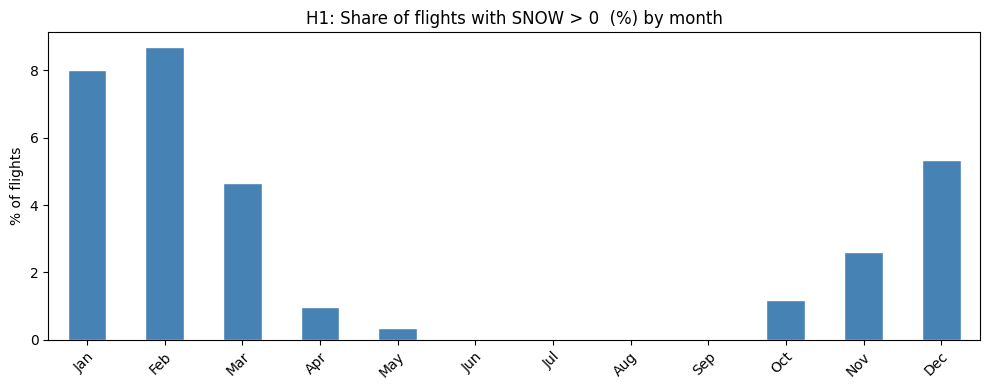

In [90]:
fig, ax = plt.subplots(figsize=(10, 4))
snow_by_month.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("H1: Share of flights with SNOW > 0  (%) by month")
ax.set_ylabel("% of flights")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

Check spring months with snow more carefully

In [97]:
snow_events = df[(df["SNOW"] > 0) & (df["MONTH_NAME"].isin(["Apr", "May"]))]

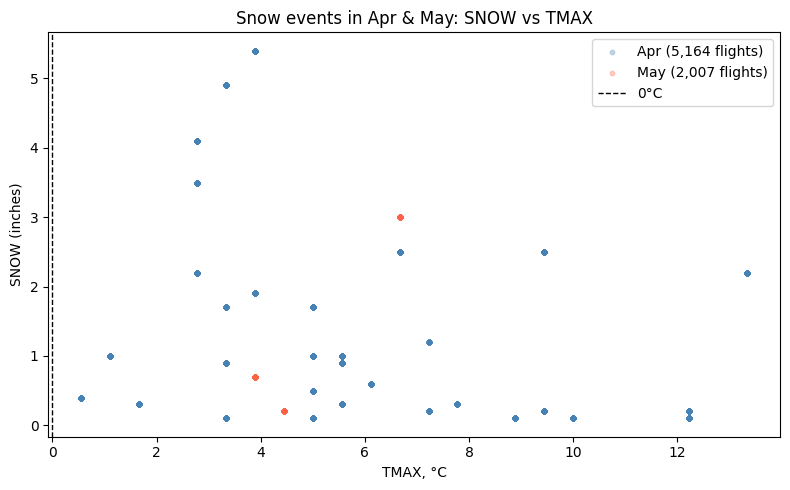

In [98]:
fig, ax = plt.subplots(figsize=(8, 5))
for month, color in [("Apr", "steelblue"), ("May", "tomato")]:
    subset = snow_events[snow_events["MONTH_NAME"] == month]
    ax.scatter(subset["TMAX_C"], subset["SNOW"],
               alpha=0.3, s=10, color=color, label=f"{month} ({len(subset):,} flights)")

ax.axvline(0, color="black", linestyle="--", linewidth=1, label="0°C")
ax.set_title("Snow events in Apr & May: SNOW vs TMAX")
ax.set_xlabel("TMAX, °C")
ax.set_ylabel("SNOW (inches)")
ax.legend()
plt.tight_layout()
plt.show()

Summary for snow

In [ ]:
for month in ["Apr", "May"]:
    subset = snow_events[snow_events["MONTH_NAME"] == month]
    above = (subset["TMAX_C"] > 2).mean() * 100
    print(f"{month}: {len(subset):,} snow events, {above:.1f}% with TMAX > 2°C (suspicious)")

Apr: 5,164 snow events, 86.1% with TMAX > 2°C (suspicious)
May: 2,007 snow events, 100.0% with TMAX > 2°C (suspicious)


Examine latitude of the airport

In [95]:
print(snow_events.groupby("MONTH_NAME")["LATITUDE"].describe().loc[["Apr","May"]])

            count  mean  std  min  25%  50%  75%  max
MONTH_NAME                                           
Apr         5,164    42    6   34   40   41   42   61
May         2,007    40    0   40   40   40   40   40


In [100]:
may_snow = df[(df["SNOW"] > 0) & (df["MONTH_NAME"] == "May")]
print(may_snow["DEPARTING_AIRPORT"].value_counts())

DEPARTING_AIRPORT
Stapleton International    2007
Name: count, dtype: int64


- Stapleton International - old name for Denver International (DEN) where snow in late spring isn't unusual
- https://www.denverpost.com/2025/04/18/denver-international-airport-delays-cancellations-snow/

2. Temperature follows seasonal pattern (TMAX ~ MONTH)

In [91]:
tmax_by_month = (
    df.groupby("MONTH_NAME")["TMAX"]
    .median()
    .reindex(MONTH_ORDER)
)

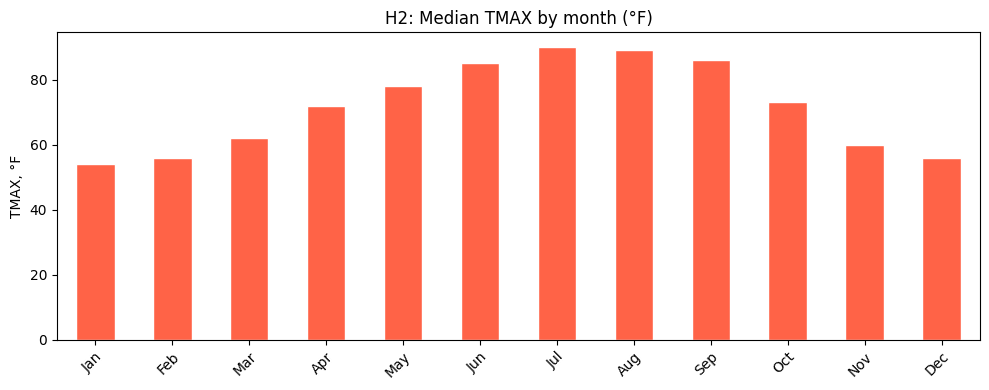

In [92]:
fig, ax = plt.subplots(figsize=(10, 4))
tmax_by_month.plot(kind="bar", ax=ax, color="tomato", edgecolor="white")
ax.set_title("H2: Median TMAX by month (°F)")
ax.set_ylabel("TMAX, °F")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

We'll convert Farengheight to Celicius and check again with more common measure

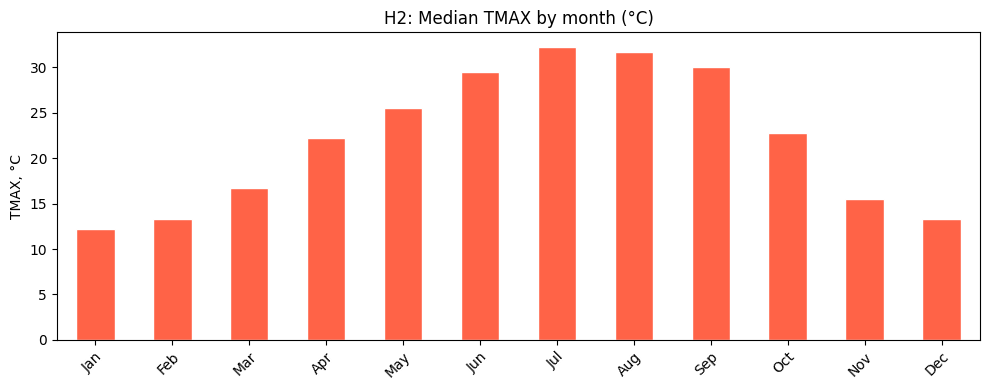

In [ ]:
tmax_by_month = (
    df.groupby("MONTH_NAME")["TMAX_C"]
    .median()
    .reindex(MONTH_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 4))
tmax_by_month.plot(kind="bar", ax=ax, color="tomato", edgecolor="white")
ax.set_title("H2: Median TMAX by month (°C)")
ax.set_ylabel("TMAX, °C")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

# 5. Data preparation

## Handling Outliers

- Outliers were inspected but not removed from the primary dataset. 
- In the context of flight delays, extreme values in weather, airport traffic, distance, or aircraft-related features may represent real operational conditions rather than data errors. 
- Therefore, plausible outliers were kept. 
- Tree-based models were trained on the primary dataset, while robust scaling will be applied for distance-based models such as KNN, which are more sensitive to extreme values and feature scale.

Run isolation forest

In [12]:
IF_FEATURES = [
    # flight operation
    "DISTANCE_GROUP", "SEGMENT_NUMBER", "NUMBER_OF_SEATS", "PLANE_AGE", "CONCURRENT_FLIGHTS",
    # airport / airline traffic
    "AIRPORT_FLIGHTS_MONTH", "AIRLINE_FLIGHTS_MONTH", "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT", "AVG_MONTHLY_PASS_AIRLINE",
    # weather
    "PRCP", "SNOW", "SNWD", "TMAX", "AWND",
]

In [13]:
ifor = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
if_labels = ifor.fit_predict(df[IF_FEATURES])  # -1 = outlier, 1 = inlier

df_outliers = df[if_labels == -1].copy().reset_index(drop=True)

print(f"df (unchanged):  {len(df):,} rows")
print(f"Outliers:        {len(df_outliers):,}  ({len(df_outliers)/len(df):.1%})")

df (unchanged):  6,460,589 rows
Outliers:        323,030  (5.0%)


In [14]:
scores = ifor.decision_function(df[IF_FEATURES])

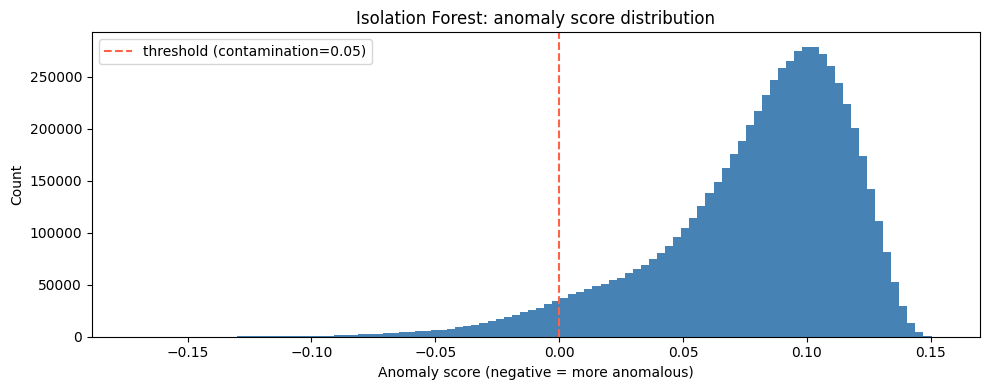

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores, bins=100, color="steelblue", edgecolor="none")
ax.axvline(0, color="tomato", linestyle="--", linewidth=1.5, label="threshold (contamination=0.05)")
ax.set_title("Isolation Forest: anomaly score distribution")
ax.set_xlabel("Anomaly score (negative = more anomalous)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

- This plot shows the distribution of Isolation Forest anomaly scores. 
- Lower scores correspond to more anomalous observations. 
- The red dashed line marks the model threshold for contamination=0.05, meaning that observations below this line are flagged as potential outliers.
- We use this plot as a diagnostic check rather than an automatic rule for removing records.


## Cardinality check

In [22]:
cat_cols = df.select_dtypes(include=["object", "category", "str"]).columns.tolist()

In [23]:
cardinality = (
    pd.DataFrame({
        "unique_values": df[cat_cols].nunique(),
        "sample_values": [df[col].value_counts().index[:3].tolist() for col in cat_cols],
    })
    .sort_values("unique_values", ascending=False)
)

In [24]:
cardinality

,unique_values,sample_values
PREVIOUS_AIRPORT,356,"[NONE, Atlanta Municipal, Chicago O'Hare International]"
DEPARTING_AIRPORT,96,"[Atlanta Municipal, Chicago O'Hare International, Dallas Fort Worth Regional]"
DEP_TIME_BLK,19,"[0800-0859, 0700-0759, 0600-0659]"
CARRIER_NAME,17,"[Southwest Airlines Co., Delta Air Lines Inc., American Airlines Inc.]"
MONTH_NAME,12,"[Aug, Jul, Oct]"
DAY_NAME,7,"[Fri, Mon, Thu]"


So, PREVIOUS_AIRPORT and DEPARTING_AIRPORT are the highest cardinality features.\
We'll do for them another type of encoding (not just one-hot)

## 6. Feature engineering

Firstly, we have to delete duplicated-meaning columns: for example, DEP_TIME_BLK <-> DEP_HOUR

In [13]:
drop_duplicates = ["DEP_TIME_BLK", "MONTH_NAME", "DAY_NAME", "TMAX"]

In [14]:
df.drop(columns=drop_duplicates, inplace=True)

In [15]:
print(df.shape)
print(df.columns.tolist())

(6460589, 26)
['MONTH', 'DAY_OF_WEEK', 'DEP_DEL15', 'DISTANCE_GROUP', 'SEGMENT_NUMBER', 'CONCURRENT_FLIGHTS', 'NUMBER_OF_SEATS', 'CARRIER_NAME', 'AIRPORT_FLIGHTS_MONTH', 'AIRLINE_FLIGHTS_MONTH', 'AIRLINE_AIRPORT_FLIGHTS_MONTH', 'AVG_MONTHLY_PASS_AIRPORT', 'AVG_MONTHLY_PASS_AIRLINE', 'FLT_ATTENDANTS_PER_PASS', 'GROUND_SERV_PER_PASS', 'PLANE_AGE', 'DEPARTING_AIRPORT', 'LATITUDE', 'LONGITUDE', 'PREVIOUS_AIRPORT', 'PRCP', 'SNOW', 'SNWD', 'AWND', 'DEP_HOUR', 'TMAX_C']


### Correlation with target

Pearson correlation

In [56]:
numeric_corr = df.select_dtypes(include="number").corr()["DEP_DEL15"].sort_values(ascending=False)
numeric_corr

DEP_DEL15                        1
DEP_HOUR                         0
SEGMENT_NUMBER                   0
PRCP                             0
AWND                             0
SNOW                             0
AIRPORT_FLIGHTS_MONTH            0
LONGITUDE                        0
SNWD                             0
AVG_MONTHLY_PASS_AIRPORT         0
DISTANCE_GROUP                   0
AIRLINE_AIRPORT_FLIGHTS_MONTH    0
NUMBER_OF_SEATS                  0
CONCURRENT_FLIGHTS               0
PLANE_AGE                        0
AIRLINE_FLIGHTS_MONTH            0
AVG_MONTHLY_PASS_AIRLINE         0
DAY_OF_WEEK                     -0
LATITUDE                        -0
FLT_ATTENDANTS_PER_PASS         -0
TMAX_C                          -0
GROUND_SERV_PER_PASS            -0
MONTH                           -0
Name: DEP_DEL15, dtype: float64

- First value = 1, because we the columns are the same
- For others, 0 means that there's no linear correlation

Mutual information

In [58]:
num_cols = [c for c in df.select_dtypes(include="number").columns if c != "DEP_DEL15"]

Calculate on sample due to high volume of the data

In [60]:
sample = df.sample(n=500_000, random_state=42)

In [61]:
mi_scores = mutual_info_classif(sample[num_cols], sample["DEP_DEL15"], random_state=42)

In [62]:
mi = (
    pd.Series(mi_scores, index=num_cols)
    .sort_values(ascending=False)
)

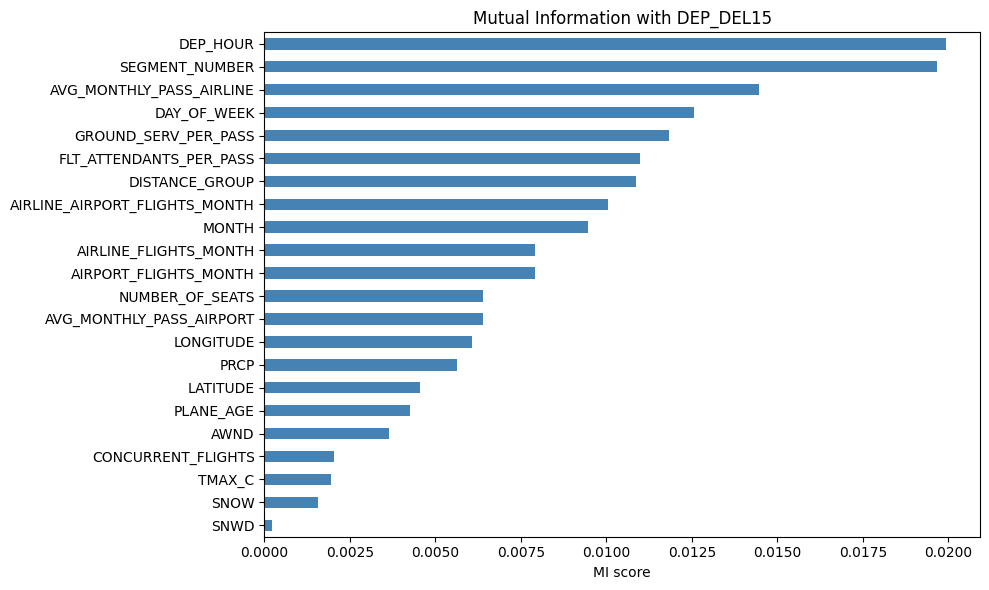

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))
mi.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Mutual Information with DEP_DEL15")
ax.set_xlabel("MI score")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

 The MI scores are low in absolute terms, but they help rank features: DEP_HOUR, SEGMENT_NUMBER, and airline/airport traffic variables appear relatively more informative than the others.


### Data binning

Time of day

In [15]:
df["DEP_HOUR_BIN"] = pd.cut(
    df["DEP_HOUR"],
    bins=4,
    labels=["night", "morning", "afternoon", "evening"]
)

In [16]:
df["DEP_HOUR_BIN"].value_counts().sort_index()

DEP_HOUR_BIN
night         146278
morning      2484289
afternoon    2290694
evening      1539328
Name: count, dtype: int64

In [19]:
df.groupby("DEP_HOUR_BIN", observed=True)["DEP_HOUR"].apply(lambda x: sorted(x.unique()))

DEP_HOUR_BIN
night                             [0]
morning          [6, 7, 8, 9, 10, 11]
afternoon    [12, 13, 14, 15, 16, 17]
evening      [18, 19, 20, 21, 22, 23]
Name: DEP_HOUR, dtype: object

Plane age

In [16]:
df["PLANE_AGE_BIN"] = pd.cut(
    df["PLANE_AGE"],
    bins=4,
    labels=["new", "middle", "old", "very_old"]
)

Distance

In [17]:
df["DISTANCE_GROUP_BIN"] = pd.cut(
    df["DISTANCE_GROUP"],
    bins=3,
    labels=["short", "medium", "long"]
)

In [73]:
for col, bin_col in [("PLANE_AGE", "PLANE_AGE_BIN"), ("DISTANCE_GROUP", "DISTANCE_GROUP_BIN")]:
    print(f"\n{bin_col}:")
    print(df.groupby(bin_col, observed=True)[col].apply(lambda x: sorted(x.unique())))


PLANE_AGE_BIN:
PLANE_AGE_BIN
new              [0, 1, 2, 3, 4, 5, 6, 7, 8]
middle       [9, 10, 11, 12, 13, 14, 15, 16]
old         [17, 18, 19, 20, 21, 22, 23, 24]
very_old    [25, 26, 27, 28, 29, 30, 31, 32]
Name: PLANE_AGE, dtype: object

DISTANCE_GROUP_BIN:
DISTANCE_GROUP_BIN
short       [1, 2, 3, 4]
medium         [5, 6, 7]
long      [8, 9, 10, 11]
Name: DISTANCE_GROUP, dtype: object


Feature - is first flight

In [18]:
df["IS_FIRST_FLIGHT"] = (df["PREVIOUS_AIRPORT"] == "NONE").astype(int)

Traffic features

In [19]:
traffic_cols = [
    "AIRPORT_FLIGHTS_MONTH", "AIRLINE_FLIGHTS_MONTH",
    "AIRLINE_AIRPORT_FLIGHTS_MONTH", "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE", "FLT_ATTENDANTS_PER_PASS",
    "GROUND_SERV_PER_PASS",
]

In [21]:
df.sample(n=100_000, random_state=42)[traffic_cols].corr().round(4)

,AIRPORT_FLIGHTS_MONTH,AIRLINE_FLIGHTS_MONTH,AIRLINE_AIRPORT_FLIGHTS_MONTH,AVG_MONTHLY_PASS_AIRPORT,AVG_MONTHLY_PASS_AIRLINE,FLT_ATTENDANTS_PER_PASS,GROUND_SERV_PER_PASS
AIRPORT_FLIGHTS_MONTH,1,-0,1,1,0,0,0
AIRLINE_FLIGHTS_MONTH,-0,1,0,-0,1,0,-0
AIRLINE_AIRPORT_FLIGHTS_MONTH,1,0,1,1,0,0,0
AVG_MONTHLY_PASS_AIRPORT,1,-0,1,1,0,0,0
AVG_MONTHLY_PASS_AIRLINE,0,1,0,0,1,0,0
FLT_ATTENDANTS_PER_PASS,0,0,0,0,0,1,0
GROUND_SERV_PER_PASS,0,-0,0,0,0,0,1


In [20]:
drop_traffic_cols = [
    "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE",
]

In [21]:
df.drop(columns=drop_traffic_cols, inplace=True)

# 6. Model-specific data preparation and modeling

### Define Features and Target

In [22]:
target = "DEP_DEL15"

numeric_features = [
    "DEP_HOUR",
    "SEGMENT_NUMBER",
    "DAY_OF_WEEK",
    "DISTANCE_GROUP",
    "MONTH",
    "NUMBER_OF_SEATS",
    "PLANE_AGE",
    "PRCP",
    "AWND",
    "SNOW",
    "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH",
    "FLT_ATTENDANTS_PER_PASS",
    "GROUND_SERV_PER_PASS",
    "CONCURRENT_FLIGHTS",
    "TMAX_C"
]

categorical_features = [
    "CARRIER_NAME",
    "DEPARTING_AIRPORT",
    "PREVIOUS_AIRPORT",
]

engineered_features = [
    "IS_FIRST_FLIGHT",
]

drop_features = [
    # redundant date/time labels
    "MONTH_NAME",
    "DAY_NAME",
    "DEP_TIME_BLK",

    # redundant traffic features based on correlation analysis
    "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE",

    # not selected for modeling
    "LATITUDE",
    "LONGITUDE",
    "TMAX"
]

model_features = numeric_features + categorical_features + engineered_features

X = df[model_features].copy()
y = df[target].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6460589, 20)
y shape: (6460589,)


### Train/Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y #due to unbalanced classes
)

## K-nearest neighbours model

In [58]:
knn_numeric_features = [
    "DEP_HOUR", "SEGMENT_NUMBER", "DAY_OF_WEEK", "DISTANCE_GROUP", "MONTH",
    "NUMBER_OF_SEATS", "PLANE_AGE", "CONCURRENT_FLIGHTS",
    "PRCP", "AWND", "SNOW", "TMAX_C",
    "AIRPORT_FLIGHTS_MONTH", "AIRLINE_FLIGHTS_MONTH",
    "FLT_ATTENDANTS_PER_PASS", "GROUND_SERV_PER_PASS", "IS_FIRST_FLIGHT",
]

knn_low_cardinality_features = ["CARRIER_NAME"]
knn_high_cardinality_features = ["DEPARTING_AIRPORT", "PREVIOUS_AIRPORT"]

Isolation forest on X Train for outliers

In [59]:
iforest_features = [
    "DISTANCE_GROUP",
    "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS",
    "NUMBER_OF_SEATS",
    "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH",
    "PLANE_AGE",
    "PRCP",
    "SNOW",
    "TMAX_C",
    "AWND",
]

iforest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

iforest.fit(X_train[iforest_features])

X_train = X_train.copy()
X_test = X_test.copy()

X_train["IS_OUTLIER"] = (iforest.predict(X_train[iforest_features]) == -1).astype(int)
X_test["IS_OUTLIER"] = (iforest.predict(X_test[iforest_features]) == -1).astype(int)

print("Outlier rate train:", X_train["IS_OUTLIER"].mean().round(3))
print("Outlier rate test: ", X_test["IS_OUTLIER"].mean().round(3))


Outlier rate train: 0.05
Outlier rate test:  0.05


Add feature Is_outlier to the dataset

In [60]:
# Add the outlier flag to KNN numeric features
knn_numeric_features = knn_numeric_features + ["IS_OUTLIER"]

knn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), knn_numeric_features),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), knn_low_cardinality_features),
        ("te", TargetEncoder(smooth="auto"), knn_high_cardinality_features),
    ],
    remainder="drop"
)

knn_pipeline = Pipeline(
    steps=[
        ("preprocessing", knn_preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]
)

In [61]:
knn_features = (
    knn_numeric_features
    + knn_low_cardinality_features
    + knn_high_cardinality_features
)

missing_cols = set(knn_features) - set(X_train.columns)

if missing_cols:
    print(f"Missing columns in X_train: {missing_cols}")
else:
    print("All KNN features are available.")

All KNN features are available.


Sampling for Knn model

Because KNN is a distance-based lazy learner, prediction requires comparing each test instance with the training set. Due to the dataset size, KNN was trained and evaluated on a stratified sample to keep computation feasible.

In [62]:
X_train_knn_sample = X_train.sample(n=100_000, random_state=42)
y_train_knn_sample = y_train.loc[X_train_knn_sample.index]

X_test_knn_sample = X_test.sample(n=20_000, random_state=42)
y_test_knn_sample = y_test.loc[X_test_knn_sample.index]

In [63]:
print(f"Train delay rate: {y_train_knn_sample.mean():.3f}")
print(f"Test delay rate:  {y_test_knn_sample.mean():.3f}")

Train delay rate: 0.189
Test delay rate:  0.189


KNN Model Training

In [64]:
knn_pipeline.fit(X_train_knn_sample, y_train_knn_sample)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

Prediction

In [50]:
y_knn_pred = knn_pipeline.predict(X_test_knn_sample)

Knn results metrics

In [65]:
print("KNN results")
print(f"Accuracy:  {accuracy_score(y_test_knn_sample, y_knn_pred):.3f}")
print(f"Precision: {precision_score(y_test_knn_sample, y_knn_pred):.3f}")
print(f"Recall:    {recall_score(y_test_knn_sample, y_knn_pred):.3f}")
print(f"F1-score:  {f1_score(y_test_knn_sample, y_knn_pred):.3f}")

print("\nClassification report:")
print(classification_report(y_test_knn_sample, y_knn_pred))

KNN results
Accuracy:  0.782
Precision: 0.253
Recall:    0.078
F1-score:  0.120

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88     16225
           1       0.25      0.08      0.12      3775

    accuracy                           0.78     20000
   macro avg       0.53      0.51      0.50     20000
weighted avg       0.71      0.78      0.73     20000



Plotting ROC AUC curve for train and test

In [38]:
def plot_roc_curve(pipeline, X_train, y_train, X_test, y_test, title="ROC Curve"):
    train_proba = pipeline.predict_proba(X_train)[:, 1]
    test_proba  = pipeline.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_proba)
    test_auc  = roc_auc_score(y_test,  test_proba)

    fig, ax = plt.subplots(figsize=(7, 5))

    for fpr, tpr, label, auc in [
        (*roc_curve(y_train, train_proba)[:2], "Train", train_auc),
        (*roc_curve(y_test,  test_proba)[:2],  "Test",  test_auc),
    ]:
        ax.plot(fpr, tpr, label=f"{label} ROC-AUC = {auc:.3f}")

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
    ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title=title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

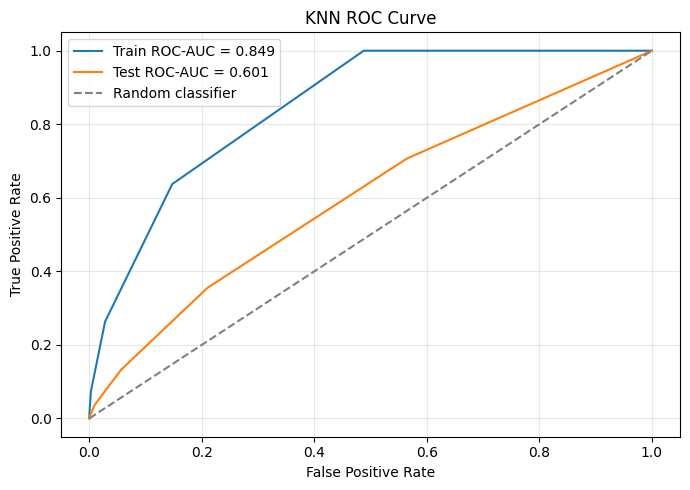

In [51]:
plot_roc_curve(knn_pipeline, X_train_knn_sample, y_train_knn_sample,
                              X_test_knn_sample,  y_test_knn_sample,
               title="KNN ROC Curve")

Confusion matrix

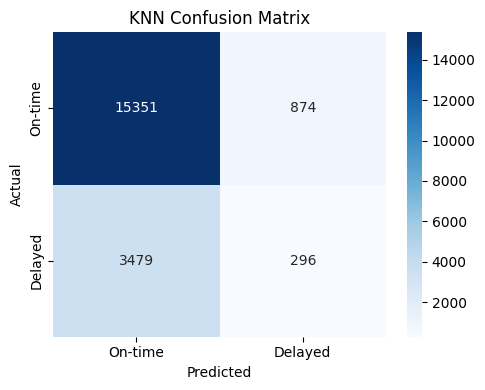

In [66]:
cm = confusion_matrix(y_test_knn_sample, y_knn_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On-time", "Delayed"],
    yticklabels=["On-time", "Delayed"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

- KNN shows signs of overfitting: ROC-AUC is much higher on train than on test, meaning the model captures local training patterns but generalizes poorly.
- KNN is also computationally expensive for this dataset, since predictions require distance calculations against many training observations. Therefore, it is kept mainly as a baseline, while further modeling focuses on more scalable tree-based models.

## Reduced cardinality for Knn

### PCA

In [67]:
knn_pca_pipeline = Pipeline(
    steps=[
        ("preprocessing", knn_preprocessor),
        ("pca",           PCA(n_components=0.95)),
        ("model",         KNeighborsClassifier(n_neighbors=5, algorithm="ball_tree", n_jobs=-1)),
    ]
)

In [68]:
knn_pca_pipeline.fit(X_train_knn_sample, y_train_knn_sample)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

Prediction

In [70]:
y_knn_pca_pred = knn_pca_pipeline.predict(X_test_knn_sample)

Knn results metrics

In [71]:
print("KNN results")
print(f"Accuracy:  {accuracy_score(y_test_knn_sample, y_knn_pred):.3f}")
print(f"Precision: {precision_score(y_test_knn_sample, y_knn_pred):.3f}")
print(f"Recall:    {recall_score(y_test_knn_sample, y_knn_pred):.3f}")
print(f"F1-score:  {f1_score(y_test_knn_sample, y_knn_pred):.3f}")

print("\nClassification report:")
print(classification_report(y_test_knn_sample, y_knn_pred))

KNN results
Accuracy:  0.782
Precision: 0.253
Recall:    0.078
F1-score:  0.120

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88     16225
           1       0.25      0.08      0.12      3775

    accuracy                           0.78     20000
   macro avg       0.53      0.51      0.50     20000
weighted avg       0.71      0.78      0.73     20000



Plotting ROC AUC curve for train and test

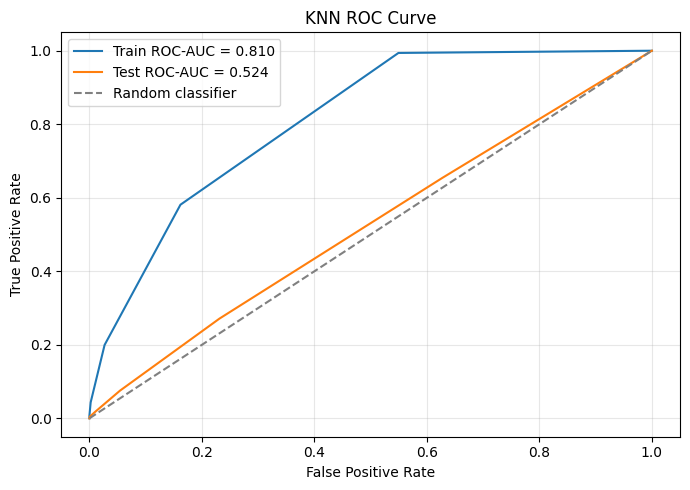

In [77]:
plot_roc_curve(knn_pca_pipeline, X_train_knn_sample, y_train_knn_sample,
                              X_test_knn_sample,  y_test_knn_sample,
               title="KNN ROC Curve")

Confusion matrix

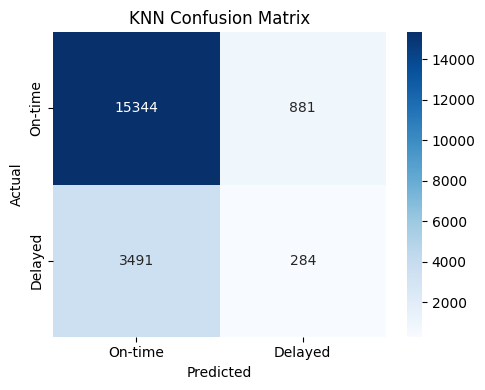

In [73]:
cm = confusion_matrix(y_test_knn_sample, y_knn_pca_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On-time", "Delayed"],
    yticklabels=["On-time", "Delayed"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

PCA was tested before KNN, but it reduced both train and test ROC-AUC. Since PCA is unsupervised, it preserves variance rather than target-relevant information, so useful predictive patterns may have been lost. Therefore, PCA was not kept in the final KNN setup.